**Name:  Lucas Jones**
_____________________________
Homework 2
CSCI 347
Show your work. Include any code snippets that you used to generate
answers. Complete this assignment individually.
Use the following data matrix to answer the questions.

![Data Matrix](datamatrix.png) 

**SETUP**

In [14]:
import pandas as pd

df = pd.DataFrame({
    'X1': ['yes', 'no', 'maybe', 'yes', 'yes', 'maybe', 'no'],
    'X2': ['on', 'off', 'off', 'off', 'on', 'off', 'on'],
    'X3': ['car', 'truck', 'rv', 'van', 'van', 'car', 'truck'],
    'X4': [1.23, 6.25, 12.25, 14.3, 9.23, 45.2, 21.3],
    'X5': [21.5, 45.2, 100.2, 32.1, 54.2, 17.1, 12.0]
})

1. Use matplotlib to create a bar plot for the counts of the variable 𝑋3.
[5 points]

<function matplotlib.pyplot.show(close=None, block=None)>

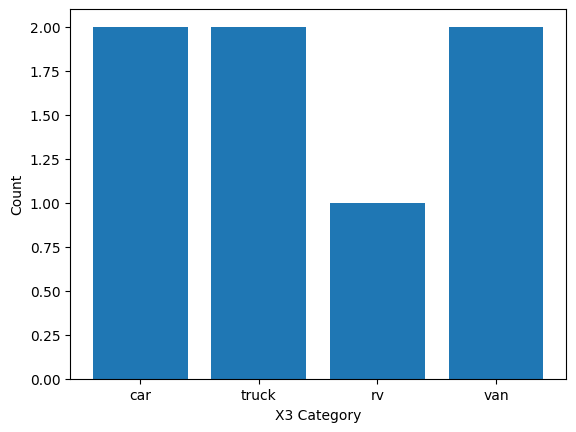

In [15]:
import matplotlib.pyplot as plt

X3_names = ['car', 'truck', 'rv', 'van']

Name_counts = [
    sum(df['X3'] == 'car'),
    sum(df['X3'] == 'truck'),
    sum(df['X3'] == 'rv'),
    sum(df['X3'] == 'van'),
]

plt.bar(X3_names, Name_counts)
plt.xlabel('X3 Category')
plt.ylabel('Count')
plt.show


2. Create a scatter plot for the variables 𝑋4 and 𝑋5. [4 points]

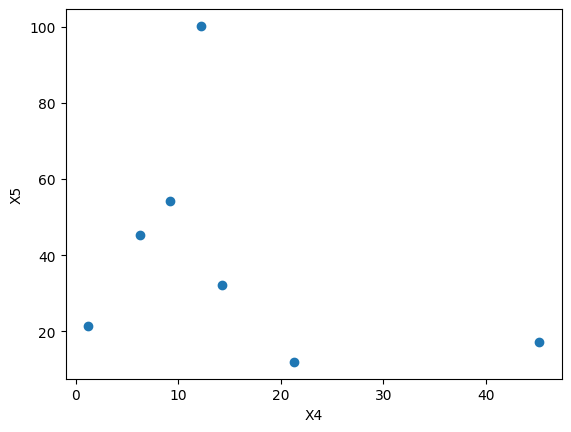

In [16]:
plt.scatter(df['X4'], df['X5'])
plt.xlabel('X4')
plt.ylabel('X5')
plt.show()


3. Use one-hot encoding to transform all the categorical attributes to
numerical values. Write down the transformed matrix. Make sure
that you do not have the original categorical data attributes. We will
refer to this transformed matrix as T for the following questions. [3
points]


In [17]:
T = pd.get_dummies(df, columns=['X1', 'X2', 'X3'], dtype= int)
T

,X4,X5,X1_maybe,X1_no,X1_yes,X2_off,X2_on,X3_car,X3_rv,X3_truck,X3_van
0,1.23,21.5,0,0,1,0,1,1,0,0,0
1,6.25,45.2,0,1,0,1,0,0,0,1,0
2,12.25,100.2,1,0,0,1,0,0,1,0,0
3,14.30,32.1,0,0,1,1,0,0,0,0,1
4,9.23,54.2,0,0,1,0,1,0,0,0,1
5,45.20,17.1,1,0,0,1,0,1,0,0,0
6,21.30,12.0,0,1,0,0,1,0,0,1,0


4. What is the 𝐿3 norm between the entities 𝑥3 and 𝑥6 after applying
the one-hot encoding (in T). [3 points]

In [18]:
import numpy as np

l3Norm = np.linalg.norm(T.iloc[2] - T.iloc[5], ord=3)

print("L3 Norm is: ", l3Norm)

L3 Norm is:  84.79220701157693


5. What is the cosine similarity (cosine of the angle) between the data
instances 𝑥3 and 𝑥6 (after applying one-hot encoding) in T. [4 points]

In [19]:
cos_sim = np.dot(T.iloc[2].values, T.iloc[5].values) / (np.linalg.norm(T.iloc[2].values) * np.linalg.norm(T.iloc[5].values))
print("Cosine Similarity is:", cos_sim)

Cosine Similarity is: 0.4647722862829796


6. What is the hamming distance between instances 𝑥3 and 𝑥6 (use
only the categorical attributes) after applying the one-hot encoding.
[3 points]

In [20]:
colSelect = T.columns.difference(['X4', 'X5'])

def hammingDistance(row1, row2):
    return sum(row1 != row2)

distance = hammingDistance(T.loc[2, colSelect], T.loc[5, colSelect])
print("Hamming Distance is:", distance)

Hamming Distance is: 2


7. What is the Jaccard similarity between the instances 𝑥3 and 𝑥6 (use
only the categorical attributes) after applying the one-hot encoding.
[3 points]

In [21]:
x3 = T.loc[2, colSelect].values
x6 = T.loc[5, colSelect].values
jaccSimilarity = np.sum((x3 & x6)) / np.sum((x3 | x6))
print("Jaccard Similarity is:", jaccSimilarity)

Jaccard Similarity is: 0.5


8. What is the multi-dimensional mean of the transformed data matrix
T. [2 points]

In [22]:
columnMeans = T.mean().values
print("Multi-Dimensional Mean:",columnMeans)

Multi-Dimensional Mean: [15.68       40.32857143  0.28571429  0.28571429  0.42857143  0.57142857
  0.42857143  0.28571429  0.14285714  0.28571429  0.28571429]


9. What is the estimated covariance between the attributes 𝑋4 and 𝑋5
in T. [3 points]

In [23]:
cov_array = np.vstack((T['X4'].values, T['X5'].values))
cov_matrix = np.cov(cov_array)
print(cov_matrix)

[[ 209.33566667 -150.3755    ]
 [-150.3755      927.50571429]]


**Estimated Covariance = -150.3755**

10. What is the estimated variance of the attribute 𝑋5 in T? [3 points]


In [24]:
X5var = T['X5'].var()
print("Estimated Variance:", X5var)

Estimated Variance: 927.5057142857145


11. What is the resulting matrix after applying standard (z-score)
normalization to 𝑇? (Let’s call this matrix 𝑍) [3 points]

In [25]:
Z = (T - T.mean() / T.std(ddof=1))
print(Z)

          X4         X5  X1_maybe    X1_no    X1_yes    X2_off     X2_on  \
0   0.146262  20.175797  -0.58554 -0.58554  0.198216 -1.069045  0.198216   
1   5.166262  43.875797  -0.58554  0.41446 -0.801784 -0.069045 -0.801784   
2  11.166262  98.875797   0.41446 -0.58554 -0.801784 -0.069045 -0.801784   
3  13.216262  30.775797  -0.58554 -0.58554  0.198216 -0.069045 -0.801784   
4   8.146262  52.875797  -0.58554 -0.58554  0.198216 -1.069045  0.198216   
5  44.116262  15.775797   0.41446 -0.58554 -0.801784 -0.069045 -0.801784   
6  20.216262  10.675797  -0.58554  0.41446 -0.801784 -1.069045  0.198216   

    X3_car     X3_rv  X3_truck   X3_van  
0  0.41446 -0.377964  -0.58554 -0.58554  
1 -0.58554 -0.377964   0.41446 -0.58554  
2 -0.58554  0.622036  -0.58554 -0.58554  
3 -0.58554 -0.377964  -0.58554  0.41446  
4 -0.58554 -0.377964  -0.58554  0.41446  
5  0.41446 -0.377964  -0.58554 -0.58554  
6 -0.58554 -0.377964   0.41446 -0.58554  


12. What is the multi-dimensional mean of 𝑍? [3 points]


In [26]:
columnMeans = Z.mean().values
print("Multi-Dimensional Mean:", columnMeans)

Multi-Dimensional Mean: [14.59626165 39.00436851 -0.29982576 -0.29982576 -0.3732123  -0.4976164
 -0.3732123  -0.29982576 -0.23510733 -0.29982576 -0.29982576]
